---
title: "Longest Collatz Sequence"
subtitle: "Project Euler — Problem 14"
author: "Ashish Kumar"
date: last-modified
categories: [Python, Project Euler, Number Theory]
jupyter: python3
toc: true
toc-depth: 3
code-fold: true
execute:
  echo: true
  warning: false
---

The **Collatz conjecture** is one of the best examples of a problem that is very easy to state but extraordinarily difficult to prove.

In this article, we will:

1. define the Collatz map mathematically;
2. state the Collatz conjecture precisely;
3. understand why it is still a conjecture rather than a theorem;
4. investigate several Collatz sequences using Python;
5. formulate Project Euler Problem 14;
6. solve the finite Project Euler problem mathematically;
7. implement the solution efficiently using Python; and
8. discuss mathematical ideas connected with the conjecture.

## 1. The Collatz map

Let $\mathbb{N}=\{1,2,3,\ldots\}$ denote the set of positive integers.

For every $n\in\mathbb{N}$, define the **Collatz map**

$$
T(n)=
\begin{cases}
\dfrac{n}{2}, & \text{if } n \text{ is even},\\[6pt]
3n+1, & \text{if } n \text{ is odd}.
\end{cases}
$$

Starting from a positive integer $n$, we repeatedly apply $T$:

$$
n,\;T(n),\;T^2(n),\;T^3(n),\ldots
$$

Here, $T^k(n)$ means that the map $T$ has been applied $k$ times.

The resulting list of numbers is called the **Collatz orbit** or **Collatz sequence** of $n$.

## 2. Statement of the Collatz conjecture

> **Collatz Conjecture.**  
> For every positive integer $n$, repeated application of the Collatz map eventually produces the number $1$.

Equivalently, for every $n\in\mathbb{N}$, there exists some non-negative integer $k$ such that

$$
T^k(n)=1.
$$

After reaching $1$, the sequence enters the cycle

$$
1\longrightarrow4\longrightarrow2\longrightarrow1.
$$

When studying stopping times or chain lengths, we normally stop the sequence at its **first occurrence of $1$**.

### Example: starting from $13$

Since $13$ is odd,

$$
13\longrightarrow 3(13)+1=40.
$$

We continue by checking whether every new term is even or odd:

$$
13\rightarrow40\rightarrow20\rightarrow10\rightarrow5
\rightarrow16\rightarrow8\rightarrow4\rightarrow2\rightarrow1.
$$

This sequence contains

$$
\boxed{10\text{ terms}}
$$

and requires

$$
\boxed{9\text{ steps}}
$$

to reach $1$.

Thus,

$$
\text{number of steps}
=
\text{number of terms}-1.
$$

## 3. Why is it still a conjecture?

A mathematical statement becomes a **theorem** only after a logically complete proof has been found.

The Collatz rule has been tested computationally for enormously many starting integers, and every tested value has eventually reached $1$. However, checking any finite collection of integers cannot prove a statement about **all** positive integers.

There are infinitely many possible starting values:

$$
1,2,3,\ldots
$$

No matter how many cases a computer verifies, infinitely many cases remain.

A complete proof must rule out both of the following possibilities:

1. **A divergent orbit:** a starting value whose sequence grows without bound.
2. **A non-trivial cycle:** a loop different from $1\to4\to2\to1$.

Neither possibility has been proved impossible for every positive integer. Therefore, the statement remains a conjecture.

The difficulty comes from the competition between two operations:

- division by $2$, which decreases a number;
- multiplication by $3$ followed by adding $1$, which increases an odd number.

The parity pattern of future terms is highly irregular, so local decreases do not easily produce a global proof.

## 4. Generating a Collatz sequence with Python

The following function stores the starting number and repeatedly applies the Collatz rule until the first occurrence of $1$.

In [2]:
def collatz_sequence(n):
    """Return the Collatz sequence beginning at the positive integer n."""
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n must be a positive integer")

    sequence = [n]

    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

        sequence.append(n)

    return sequence

In [3]:
sequence_13 = collatz_sequence(13)
sequence_13

[13, 40, 20, 10, 5, 16, 8, 4, 2, 1]

The length of the Python list gives the number of terms. Subtracting $1$ gives the number of steps.

In [4]:
print("Number of terms:", len(sequence_13))
print("Number of steps:", len(sequence_13) - 1)

Number of terms: 10
Number of steps: 9


## 5. Experimental verification using Python

A computer experiment can verify the conjecture for selected starting values, but it cannot prove the conjecture for every positive integer.

For each tested value, we record:

- its starting value;
- the number of terms;
- the number of steps needed to reach $1$; and
- the greatest value reached in the sequence.

In [5]:
def collatz_summary(n):
    sequence = collatz_sequence(n)

    return {
        "Start": n,
        "Terms": len(sequence),
        "Steps": len(sequence) - 1,
        "Maximum value": max(sequence),
    }


test_values = [6, 10, 13, 19, 27, 97]
summaries = [collatz_summary(n) for n in test_values]
summaries

[{'Start': 6, 'Terms': 9, 'Steps': 8, 'Maximum value': 16},
 {'Start': 10, 'Terms': 7, 'Steps': 6, 'Maximum value': 16},
 {'Start': 13, 'Terms': 10, 'Steps': 9, 'Maximum value': 40},
 {'Start': 19, 'Terms': 21, 'Steps': 20, 'Maximum value': 88},
 {'Start': 27, 'Terms': 112, 'Steps': 111, 'Maximum value': 9232},
 {'Start': 97, 'Terms': 119, 'Steps': 118, 'Maximum value': 9232}]

In [6]:
import pandas as pd

pd.DataFrame(summaries)

,Start,Terms,Steps,Maximum value
0,6,9,8,16
1,10,7,6,16
2,13,10,9,40
3,19,21,20,88
4,27,112,111,9232
5,97,119,118,9232


The starting value $27$ is a famous small example. Although it begins below $30$, its orbit rises to $9232$ before eventually reaching $1$.

In [7]:
sequence_27 = collatz_sequence(27)

print("Terms:", len(sequence_27))
print("Steps:", len(sequence_27) - 1)
print("Maximum value:", max(sequence_27))

Terms: 112
Steps: 111
Maximum value: 9232


### Visualising a Collatz trajectory

The orbit does not decrease steadily. A graph reveals its irregular upward and downward movement.

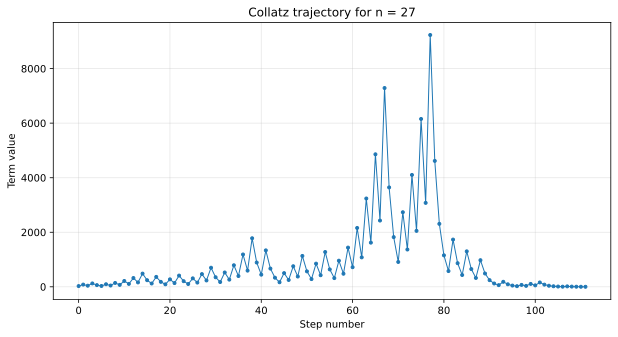

In [8]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
steps = range(len(sequence_27))

plt.figure(figsize=(10, 5))
plt.plot(steps, sequence_27, marker="o", markersize=3, linewidth=1)
plt.xlabel("Step number")
plt.ylabel("Term value")
plt.title("Collatz trajectory for n = 27")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Project Euler Problem 14

**Project Euler Problem 14 — Longest Collatz Sequence**

Among all starting integers satisfying

$$
1\leq n<1{,}000{,}000,
$$

determine the starting value that produces the longest Collatz chain before reaching $1$.

Only the **starting value** must be below one million. Terms appearing later in its chain are allowed to exceed one million.

The example supplied in the problem is

$$
13\rightarrow40\rightarrow20\rightarrow10\rightarrow5
\rightarrow16\rightarrow8\rightarrow4\rightarrow2\rightarrow1,
$$

which contains $10$ terms.

## 7. Mathematical formulation of the solution

Project Euler Problem 14 is not asking us to prove the Collatz conjecture. It asks us to solve a **finite search problem** involving only the starting values

$$
1,2,\ldots,999999.
$$

Assuming the tested chains reach $1$, define the **chain-length function**

$$
L(n)=\text{number of terms from }n\text{ to the first occurrence of }1.
$$

The base value is

$$
L(1)=1.
$$

For $n>1$, the first step moves from $n$ to $T(n)$. Therefore,

$$
L(n)=1+L(T(n)).
$$

Using the definition of $T$, this becomes

$$
L(n)=
\begin{cases}
1+L\left(\dfrac{n}{2}\right),
& n\text{ even},\\[8pt]
1+L(3n+1),
& n\text{ odd}.
\end{cases}
$$

Hence the required starting value is

$$
n_{\max}
=
\operatorname*{arg\,max}_{1\leq n<1{,}000{,}000}L(n).
$$

A direct mathematical procedure is therefore:

1. compute $L(n)$ for every $n<1{,}000{,}000$;
2. compare all these lengths; and
3. select the value of $n$ for which $L(n)$ is greatest.

The important observation is that different Collatz chains frequently merge. For example,

$$
13\rightarrow40\rightarrow20\rightarrow10\rightarrow\cdots
$$

and the chain beginning at $40$ has exactly the same tail. Thus, once $L(40)$ is known,

$$
L(13)=1+L(40).
$$

This repeated structure suggests storing previously calculated values of $L(n)$. In computing terminology, this is called **memoization** or **dynamic programming**.

### A small mathematical example

Suppose we already know

$$
L(10)=7,
$$

because

$$
10\rightarrow5\rightarrow16\rightarrow8\rightarrow4\rightarrow2\rightarrow1.
$$

Since

$$
20\rightarrow10,
$$

we obtain

$$
L(20)=1+L(10)=8.
$$

Similarly,

$$
L(40)=1+L(20)=9
$$

and

$$
L(13)=1+L(40)=10.
$$

Thus, one known tail gives the lengths of several earlier starting values without recomputing the complete sequence.

## 8. A direct Python solution

The simplest implementation generates the entire sequence for every starting value and compares the lengths.

In [9]:
def longest_collatz_naive(limit):
    """Find the longest Collatz chain for 1 <= n < limit."""
    best_start = 1
    best_length = 1

    for n in range(1, limit):
        current_length = len(collatz_sequence(n))

        if current_length > best_length:
            best_start = n
            best_length = current_length

    return best_start, best_length

This method is mathematically correct for the finite search, but it repeats many previously encountered tails. We can make it substantially faster by using the recurrence for $L(n)$.

## 9. Efficient Python solution using memoization

We start with the known value

$$
L(1)=1.
$$

While tracing a new orbit, we stop as soon as we reach a value whose chain length is already stored. We then work backwards through the new part of the path and calculate all missing lengths.

In [10]:
def collatz_length(n, cache):
    """Return the Collatz chain length of n using a shared cache."""
    original_n = n
    path = []

    # Continue until we reach a number with a known chain length.
    while n not in cache:
        path.append(n)

        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

    known_length = cache[n]

    # Work backwards and store the length of every new value.
    for value in reversed(path):
        known_length += 1
        cache[value] = known_length

    return cache[original_n]

In [11]:
def longest_collatz(limit):
    """Return the start, length, and cache for the longest chain below limit."""
    if not isinstance(limit, int) or isinstance(limit, bool) or limit <= 1:
        raise ValueError("limit must be an integer greater than 1")

    cache = {1: 1}
    best_start = 1
    best_length = 1

    for n in range(1, limit):
        current_length = collatz_length(n, cache)

        if current_length > best_length:
            best_start = n
            best_length = current_length

    return best_start, best_length, cache

In [12]:
best_start, best_length, length_cache = longest_collatz(1_000_000)

print(f"Starting number: {best_start:,}")
print(f"Number of terms: {best_length}")
print(f"Number of steps: {best_length - 1}")

Starting number: 837,799
Number of terms: 525
Number of steps: 524


Therefore,

$$
\operatorname*{arg\,max}_{1\leq n<1{,}000{,}000}L(n)
=
\boxed{837799}.
$$

Its Collatz chain contains

$$
\boxed{525\text{ terms}}
$$

and consequently requires

$$
\boxed{524\text{ steps}}
$$

to reach $1$.

## 10. Inspecting the winning chain

In [13]:
winning_sequence = collatz_sequence(best_start)

print("First 15 terms:")
print(winning_sequence[:15])

print("\nLast 15 terms:")
print(winning_sequence[-15:])

print(f"\nMaximum value reached: {max(winning_sequence):,}")

First 15 terms:
[837799, 2513398, 1256699, 3770098, 1885049, 5655148, 2827574, 1413787, 4241362, 2120681, 6362044, 3181022, 1590511, 4771534, 2385767]

Last 15 terms:
[70, 35, 106, 53, 160, 80, 40, 20, 10, 5, 16, 8, 4, 2, 1]

Maximum value reached: 2,974,984,576


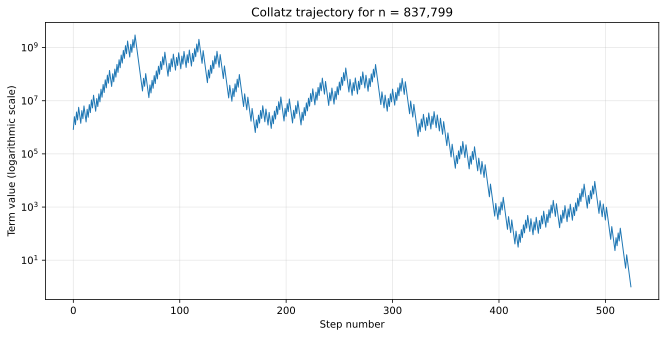

In [14]:
%config InlineBackend.figure_format = 'svg'
plt.figure(figsize=(11, 5))
plt.plot(range(len(winning_sequence)), winning_sequence, linewidth=1)
plt.yscale("log")
plt.xlabel("Step number")
plt.ylabel("Term value (logarithmic scale)")
plt.title("Collatz trajectory for n = 837,799")
plt.grid(True, alpha=0.3)
plt.show()

A logarithmic vertical scale is helpful because the orbit contains values of very different magnitudes. The chain beginning at $837799$ rises far above its starting value before eventually reaching $1$.

## 11. Mathematical ideas related to the Collatz conjecture

The Collatz conjecture is connected with several important areas of mathematics.

### 11.1 Discrete dynamical systems

The repeated iteration

$$
n,\;T(n),\;T^2(n),\ldots
$$

makes the Collatz map a **discrete dynamical system** on the positive integers.

The main dynamical questions are:

- Does every orbit reach the same cycle?
- Can an orbit escape to infinity?
- Can another periodic cycle exist?
- How long does an orbit take to fall below its starting value?

These are questions about the long-term behaviour of an iterated function.

### 11.2 Total stopping time

The **total stopping time** of $n$ is the number of iterations required to reach $1$:

$$
\sigma_\infty(n)
=
\min\{k\geq0:T^k(n)=1\}.
$$

Whenever the orbit reaches $1$,

$$
L(n)=\sigma_\infty(n)+1.
$$

For the Project Euler answer,

$$
\sigma_\infty(837799)=524.
$$

### 11.3 Stopping time

A related quantity is the first time an orbit becomes smaller than its starting value:

$$
\sigma(n)
=
\min\{k\geq1:T^k(n)<n\}.
$$

If no such $k$ exists, the stopping time is regarded as infinite.

Stopping-time arguments are useful because if every integer eventually falls below itself, strong induction would imply that every orbit reaches $1$. The unresolved difficulty is proving this decrease for every starting integer.

### 11.4 The accelerated map on odd integers

Every odd $n$ produces the even number $3n+1$. We may divide out all powers of $2$ immediately.

Let $\nu_2(m)$ denote the exponent of $2$ in the prime factorisation of $m$. For odd $n$, define the accelerated or Syracuse map

$$
S(n)
=
\frac{3n+1}{2^{\nu_2(3n+1)}}.
$$

This map sends odd integers directly to odd integers and removes the intermediate divisions by $2$.

For example,

$$
S(13)
=
\frac{3(13)+1}{2^3}
=
\frac{40}{8}
=
5.
$$

Thus, the odd part of the orbit beginning at $13$ is

$$
13\rightarrow5\rightarrow1.
$$

### 11.5 Parity vectors

Every step is determined by whether the current term is even or odd. Therefore, an orbit determines a binary parity pattern such as

$$
1,0,0,0,1,0,\ldots,
$$

where $1$ represents an odd term and $0$ represents an even term.

After fixing a finite parity pattern, the corresponding iterate can be written in the affine form

$$
T^k(n)
=
\frac{3^a n+b}{2^c},
$$

for suitable integers $a,b,c$ determined by the pattern.

This algebraic description is useful for analysing possible cycles, but the difficulty is that the parity pattern itself depends on the evolving value of $n$.

### 11.6 Probabilistic heuristic

For an odd integer, the operation $3n+1$ increases its size. However, the result is even and may be divisible by a large power of $2$.

A heuristic model treats powers of $2$ appearing in $3n+1$ as approximately random. Under this model, the repeated divisions by $2$ tend, on average, to compensate for multiplication by $3$.

This helps explain why most observed orbits eventually descend. It is only a heuristic, not a proof, because the parity events in an actual deterministic orbit are not independent random events.

### 11.7 Collatz graph

The positive integers may be represented as a directed graph in which every integer $n$ has an arrow

$$
n\longrightarrow T(n).
$$

The conjecture says that every positive integer lies in the component leading to the cycle

$$
1\rightarrow4\rightarrow2\rightarrow1.
$$

Studying predecessors instead of successors produces an inverse Collatz tree. This graph-theoretic viewpoint helps visualise how many different orbits merge into common tails.

### 11.8 Partial results

Important partial results are known, but none proves the full conjecture.

Terence Tao proved that, in a precise logarithmic-density sense, **almost all** Collatz orbits eventually attain values smaller than any function that tends to infinity. This is a powerful result about almost all starting values, but “almost all” is not the same as “every”.

Research on generalized Collatz maps also shows that closely related iteration problems can be algorithmically undecidable. This does **not** prove that the original Collatz conjecture is undecidable; it only illustrates why very simple-looking iteration rules can encode extremely complicated behaviour.

## 12. Mathematical and computational lessons

This problem illustrates several general principles.

1. **A simple rule can generate complicated behaviour.**  
   Elementary arithmetic does not guarantee an elementary proof.

2. **Experimental evidence is not mathematical proof.**  
   Testing many integers supports a conjecture but cannot establish a universal statement.

3. **The Project Euler problem is finite.**  
   We do not need to prove the Collatz conjecture to compare the chains beginning below one million.

4. **A recurrence reveals reusable structure.**  
   The identity

   $$
   L(n)=1+L(T(n))
   $$

   allows previously calculated chain lengths to be reused.

5. **Memoization converts mathematics into an efficient algorithm.**  
   The program stores known values exactly as suggested by the recurrence.

## Conclusion

The Collatz conjecture remains unsolved because no proof has shown that every positive integer must reach $1$, and no counterexample has been found.

Project Euler Problem 14 asks a more manageable finite question. By defining the chain-length function

$$
L(n)=1+L(T(n))
$$

and storing previously computed values, we can efficiently compare all starting integers below one million.

The required starting number is

$$
\boxed{837799}.
$$

Its orbit reaches $1$ after

$$
\boxed{524\text{ steps}},
$$

so the complete chain contains

$$
\boxed{525\text{ terms}}.
$$

## References and further reading

1. [Project Euler, Problem 14: Longest Collatz Sequence](https://projecteuler.net/problem=14)
2. Jeffrey C. Lagarias, [*The $3x+1$ Problem: An Overview*](https://arxiv.org/abs/2111.02635)
3. Terence Tao, [*Almost All Orbits of the Collatz Map Attain Almost Bounded Values*](https://arxiv.org/abs/1909.03562)
4. Terence Tao, [expository discussion of the result](https://terrytao.wordpress.com/2019/09/10/almost-all-collatz-orbits-attain-almost-bounded-values/)
5. Stuart A. Kurtz and Janos Simon, [*The Undecidability of the Generalized Collatz Problem*](https://link.springer.com/chapter/10.1007/978-3-540-72504-6_49)